In [1]:
!pip install -q transformers[torch]
!pip install -q accelerate -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.4/302.4 kB 4.0 MB/s eta 0:00:00


In [3]:
!pip install -q transformers evaluate
!pip install -q opencv-python==4.6.0.66

In [4]:
import os
from zipfile import ZipFile
from tqdm import tqdm
from glob import glob
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2 as cv
import pandas as pd
import torch

#CONFIG

In [6]:
DATA_PATH = 'drive/MyDrive/AD'

CLASSES = [ 'Abuse' , 'Arrest' , 'Arson' , 'Assault' , 'Normal' ]
NORMAL_CLASS = "Normal"

JSON_FILE_PATH = './class_video_mapping.json'

IMAGE_PROCESSOR_CHECKPOINT = "MCG-NJU/videomae-base"
TRANSFORMER_MODEL_CHCEKPOINT = "MCG-NJU/videomae-base"


from transformers import VideoMAEImageProcessor as TransformerImageProcessor
from transformers import VideoMAEForPreTraining as TransformerClassifier

#CODE

In [7]:
!rm -r data

rm: cannot remove 'data': No such file or directory


In [10]:
!mkdir data
for zip_file in tqdm(os.listdir(DATA_PATH)):
    with ZipFile(f'{DATA_PATH}//{zip_file}', 'r') as z:
        z.extractall(path="./data/")

mkdir: cannot create directory ‘data’: File exists


100%|██████████| 2/2 [00:51<00:00, 25.92s/it]


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
class_video_dictionary = {}

for class_name in CLASSES:
    class_video_dictionary[class_name] = []

In [12]:
def load_videos_in_dictionary(path,class_name=None):

    num_loaded_videos = 0
    lowercased_keys = [k.lower() for k in class_video_dictionary.keys()]

    for video_path in tqdm(glob(path)):


        try:

            class_ = class_name

            if class_ is None:
              class_ = video_path.split('/')[-2]
              is_valid_class = class_.lower() in lowercased_keys

            else:
              is_valid_class = True

            is_video_path = video_path.endswith('mp4')

            if( is_valid_class and is_video_path ):
                class_video_dictionary[class_].append(video_path)
                num_loaded_videos += 1

        except Exception as e:
            continue

    print(f"Loaded {num_loaded_videos} videos",end="\t")

In [13]:
def save_as_json(path,dictionary):
    json_object = json.dumps(dictionary, indent=4)
    with open(path, "w") as outfile:
        outfile.write(json_object)

In [ ]:
current_path = './data/'

for folder_name in os.listdir(current_path):

    print()
    print(folder_name,end="\t")

    if 'Anomaly' in folder_name:
        glob_path = f'./data/{folder_name}/*/*'
        class_name = None
    elif 'Normal' in folder_name:
        glob_path = f'./data/{folder_name}/*'
        class_name = NORMAL_CLASS

    load_videos_in_dictionary(glob_path,class_name)


print("\n\n")
for key in class_video_dictionary.keys():
    print(f"{key} =====================> {len(class_video_dictionary[key])}")


save_as_json(JSON_FILE_PATH,class_video_dictionary)
print("\n\nJSON SAVED")


Modified Anomaly Videos	

100%|██████████| 149/149 [00:00<00:00, 185006.30it/s]


Loaded 149 videos	
Normal_Videos_for_Event_Recognition	

100%|██████████| 50/50 [00:00<00:00, 412014.15it/s]

Loaded 50 videos	


Abuse =====================> 42
Arrest =====================> 34
Arson =====================> 23
Assault =====================> 50
Normal =====================> 50


JSON SAVED


In [16]:

save_as_json(JSON_FILE_PATH,class_video_dictionary)


In [17]:
f = open(JSON_FILE_PATH)
class_video_dictionary = json.load(f)
f.close()

<ipython-input-21-ef250e777881>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


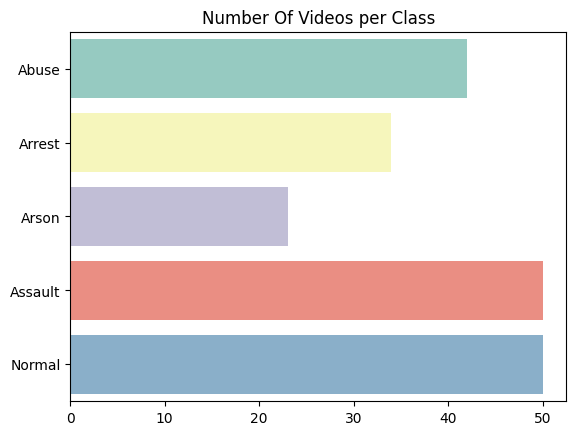

In [ ]:
sns.barplot(
      x=[len(val) for val in class_video_dictionary.values()],
      y=class_video_dictionary.keys(),
      orient='h',
      palette="Set3"
    )
plt.title("Number Of Videos per Class")
plt.show();

In [18]:
def get_duration_and_frame_count(path):

    video = cv.VideoCapture(path)

    frame_count = int(video.get(cv.CAP_PROP_FRAME_COUNT))
    duration = frame_count/video.get(cv.CAP_PROP_FPS)

    video.release()
    return duration

In [ ]:
metadata_dict = {
    "path" : [] ,
    "class" : [] ,
}
durations = []

for k in class_video_dictionary.keys():
    classes = [k]*len(class_video_dictionary[k])
    metadata_dict["path"].extend(class_video_dictionary[k])
    metadata_dict["class"].extend(classes)

for path in tqdm(metadata_dict["path"]):
    duration = get_duration_and_frame_count(path)
    durations.append(duration)

metadata_dict["duration"] = durations
metadata_df = pd.DataFrame(metadata_dict)
metadata_df.head()

100%|██████████| 199/199 [00:00<00:00, 267.08it/s]


,path,class,duration
0,./data/Modified Anomaly Videos/Abuse/Abuse012_...,Abuse,14.533333
1,./data/Modified Anomaly Videos/Abuse/Abuse016_...,Abuse,15.766667
2,./data/Modified Anomaly Videos/Abuse/Abuse047_...,Abuse,12.066667
3,./data/Modified Anomaly Videos/Abuse/Abuse031_...,Abuse,16.100000
4,./data/Modified Anomaly Videos/Abuse/Abuse022_...,Abuse,14.100000


In [24]:
metadata_dict = {
    "path" : [] ,
    "class" : [] ,
}
durations = []

for k in class_video_dictionary.keys():
    classes = [k]*len(class_video_dictionary[k])
    metadata_dict["path"].extend(class_video_dictionary[k])
    metadata_dict["class"].extend(classes)

for path in tqdm(metadata_dict["path"]):
    duration = get_duration_and_frame_count(path)
    durations.append(duration)

metadata_dict["duration"] = durations
metadata_df = pd.DataFrame(metadata_dict)


100%|██████████| 69/69 [00:00<00:00, 99.65it/s] 


<Axes: xlabel='duration', ylabel='Density'>

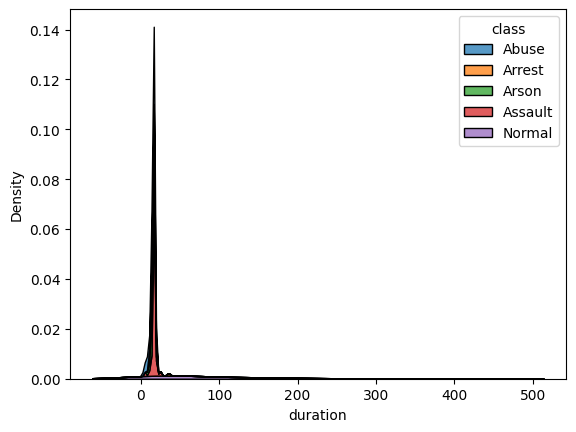

In [ ]:
sns.kdeplot(data = metadata_df, x = "duration", hue = "class" , multiple="stack")

In [ ]:
metadata_df.describe()

,duration
count,199.000000
mean,35.759464
std,62.590132
min,3.466667
25%,14.950000
50%,16.000000
75%,17.233333
max,448.633333


In [ ]:
max_duration = 240

selected_data = metadata_df[metadata_df["duration"] >= max_duration]
print(f"Number Of Rows: {len(selected_data)}")
print(f"Total Videos: {len(metadata_df)}")

print()
print()


value_counts = selected_data["class"].value_counts()
print(value_counts)


selected_data

Number Of Rows: 5
Total Videos: 199


class
Normal    5
Name: count, dtype: int64


,path,class,duration
150,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,448.633333
157,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,334.166667
171,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,375.833333
193,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,273.700000
195,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,291.033333


# LOADING TRANSFORMERS

In [19]:
image_processor = TransformerImageProcessor.from_pretrained(IMAGE_PROCESSOR_CHECKPOINT)
model = TransformerClassifier.from_pretrained(TRANSFORMER_MODEL_CHCEKPOINT)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

In [20]:
model.config

VideoMAEConfig {
  "_name_or_path": "MCG-NJU/videomae-base",
  "architectures": [
    "VideoMAEForPreTraining"
  ],
  "attention_probs_dropout_prob": 0.0,
  "decoder_hidden_size": 384,
  "decoder_intermediate_size": 1536,
  "decoder_num_attention_heads": 6,
  "decoder_num_hidden_layers": 4,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "videomae",
  "norm_pix_loss": true,
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_frames": 16,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.40.1",
  "tubelet_size": 2,
  "use_mean_pooling": false
}

In [21]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

label2id = {label: i for i, label in enumerate(CLASSES)}
id2label = {i: label for label, i in label2id.items()}

model_ckpt = "sayakpaul/videomae-base-finetuned-ucf101-subset"
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/345M [00:00<?, ?B/s]

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at sayakpaul/videomae-base-finetuned-ucf101-subset and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([10, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([10]) in the checkpoint and torch.Size([5]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)


num_frames_to_sample = model.config.num_frames
num_frames_to_sample

16

<br/>
<br/>

# LABEL ENCODING

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

unique_categories = list(metadata_df['class'].value_counts().index)

le.fit(unique_categories)

LabelEncoder()

In [26]:
classes = list(le.classes_)
transformed = list(le.transform(classes))
transformed

[0, 1, 2, 3, 4]

In [27]:
class_to_label_mapping = { k:v for (k,v) in zip(transformed,classes)}
class_to_label_mapping

{0: 'Abuse', 1: 'Arrest', 2: 'Arson', 3: 'Assault', 4: 'Normal'}

In [28]:
metadata_df["transformed_classes"] = le.transform(metadata_df["class"])

In [ ]:
metadata_df.sample(10)

,path,class,duration,transformed_classes
101,./data/Modified Anomaly Videos/Assault/Assault...,Assault,16.200000,3
172,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,38.000000,4
57,./data/Modified Anomaly Videos/Arrest/WhatsApp...,Arrest,15.633333,1
23,./data/Modified Anomaly Videos/Abuse/Abuse043_...,Abuse,16.166667,0
181,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,91.466667,4
5,./data/Modified Anomaly Videos/Abuse/Abuse048_...,Abuse,16.033333,0
194,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,35.900000,4
16,./data/Modified Anomaly Videos/Abuse/Abuse017_...,Abuse,16.000000,0
18,./data/Modified Anomaly Videos/Abuse/Abuse010_...,Abuse,14.433333,0
161,./data/Normal_Videos_for_Event_Recognition/Nor...,Normal,30.800000,4


<br/>
<br/>

# TRAIN TEST SPLIT

In [ ]:
metadata_df.head()

,path,class,duration,transformed_classes
0,./data/Modified Anomaly Videos/Abuse/Abuse012_...,Abuse,14.533333,0
1,./data/Modified Anomaly Videos/Abuse/Abuse016_...,Abuse,15.766667,0
2,./data/Modified Anomaly Videos/Abuse/Abuse047_...,Abuse,12.066667,0
3,./data/Modified Anomaly Videos/Abuse/Abuse031_...,Abuse,16.100000,0
4,./data/Modified Anomaly Videos/Abuse/Abuse022_...,Abuse,14.100000,0


In [29]:
from sklearn.model_selection import train_test_split

X = metadata_df['path']
y = metadata_df['transformed_classes']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1,stratify=y,random_state=42)

X_train.shape , y_test.shape

((62,), (7,))

In [30]:
y_train.value_counts()

transformed_classes
4    45
2     8
1     4
3     3
0     2
Name: count, dtype: int64

In [31]:
y_test.value_counts()

transformed_classes
4    5
1    1
2    1
Name: count, dtype: int64

In [32]:
X_train.reset_index(drop=True,inplace=True)
y_train.reset_index(drop=True,inplace=True)
X_test.reset_index(drop=True,inplace=True)
y_test.reset_index(drop=True,inplace=True)

In [ ]:
X_train.head()

0    ./data/Modified Anomaly Videos/Abuse/Abuse045_...
1    ./data/Modified Anomaly Videos/Arrest/WhatsApp...
2    ./data/Modified Anomaly Videos/Arrest/WhatsApp...
3    ./data/Modified Anomaly Videos/Assault/Assault...
4    ./data/Modified Anomaly Videos/Arrest/WhatsApp...
Name: path, dtype: object

<br/>
<br/>

# DATALOADER

In [33]:
from torchvision.transforms.v2 import UniformTemporalSubsample,Compose,Resize

In [34]:
transform = Compose([
    Resize(resize_to)
])

In [35]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset , DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np

class VideoLoaderDataset(Dataset):
    def __init__(self, paths , labels):
        self.video_paths = paths
        self.video_labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.video_labels)

    def get_video_frames(self,path):

        try:

          video = cv.VideoCapture(path)
          num_frames = int(video.get(cv.CAP_PROP_FRAME_COUNT))

          gap = num_frames // num_frames_to_sample
          frame_to_pick = 1
          selected_frames = []

          while (frame_to_pick <= num_frames_to_sample):
            frame_index = gap * frame_to_pick
            video.set(cv.CAP_PROP_POS_FRAMES, frame_index-1)
            ret, frame = video.read()
            resized_frame = cv.resize(frame, resize_to)
            selected_frames.append(resized_frame)
            frame_to_pick+=1

          return selected_frames

        except Exception as e:
          print(e)


    def __getitem__(self, idx):

        video_path = self.video_paths.iloc[idx]
        video_frames = self.get_video_frames(video_path)
        #print("Length: ",len(video_frames))

        video_frames = torch.tensor(np.array(video_frames),dtype=torch.float32)
        label = torch.tensor(self.video_labels.iloc[idx])
        label = label.type(torch.LongTensor)

        # if self.target_transform:
        #     label = self.target_transform(label)

        return video_frames, label

In [36]:
training_dataset = VideoLoaderDataset(X_train,y_train)
training_dataloader = DataLoader(training_dataset,batch_size=1,shuffle=True)

testing_dataset = VideoLoaderDataset(X_test,y_test)
testing_dataloader = DataLoader(testing_dataset,batch_size=1,shuffle=True)

In [37]:
train_features, train_labels = next(iter(training_dataloader))

In [38]:
train_features.shape

torch.Size([1, 16, 224, 224, 3])

In [39]:
train_labels

tensor([1])

In [40]:
a = next(iter(training_dataloader))

In [41]:
a[0].shape , a[1]

(torch.Size([1, 16, 224, 224, 3]), tensor([4]))

In [42]:
def test_dataloader(dataloader):
    try:
      for data in tqdm(dataloader):
        if(list(data[0].shape)!=[1,16,224,224,3]):
            raise Exception("Data Shape not correct")
    except Exception as e:
      print(e)

In [43]:
test_dataloader(training_dataloader)
test_dataloader(testing_dataloader)

100%|██████████| 7/7 [00:09<00:00,  1.41s/it]


<br/>
<br/>

# TRAINING

In [44]:
from transformers import TrainingArguments, Trainer


num_epochs = 4

args = TrainingArguments(
    "./after_training",
    remove_unused_columns=False,
    evaluation_strategy="steps",
    save_strategy="steps",
    learning_rate=5e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    save_steps = 110,
    eval_steps = 110
)

In [45]:
import evaluate

metric = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [46]:
def collate_fn(examples):
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example[0].permute(0, 3, 1, 2) for example in examples]
    )
    labels = torch.tensor([example[1] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [47]:
trainer = Trainer(
    model,
    args,
    train_dataset=training_dataset,
    eval_dataset=testing_dataset,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

In [48]:
train_results = trainer.train()

Step,Training Loss,Validation Loss,Accuracy
110,2.020500,1.416736,0.714286


In [50]:
trainer.save_model("./model")

In [51]:
trainer_log = trainer.state.log_history
save_as_json('./training_logs.json',trainer_log)

In [52]:
eval_loss = []
training_loss = []
training_epochs = []
testing_epochs = []
eval_acc = []

for log in trainer_log:
  if 'loss' in log.keys():
    training_loss.append(log['loss'])
    training_epochs.append(log['epoch'])
  elif 'eval_loss' in log.keys():
    testing_epochs.append(log['epoch'])
    eval_loss.append(log['eval_loss'])
    eval_acc.append(log['eval_accuracy'])

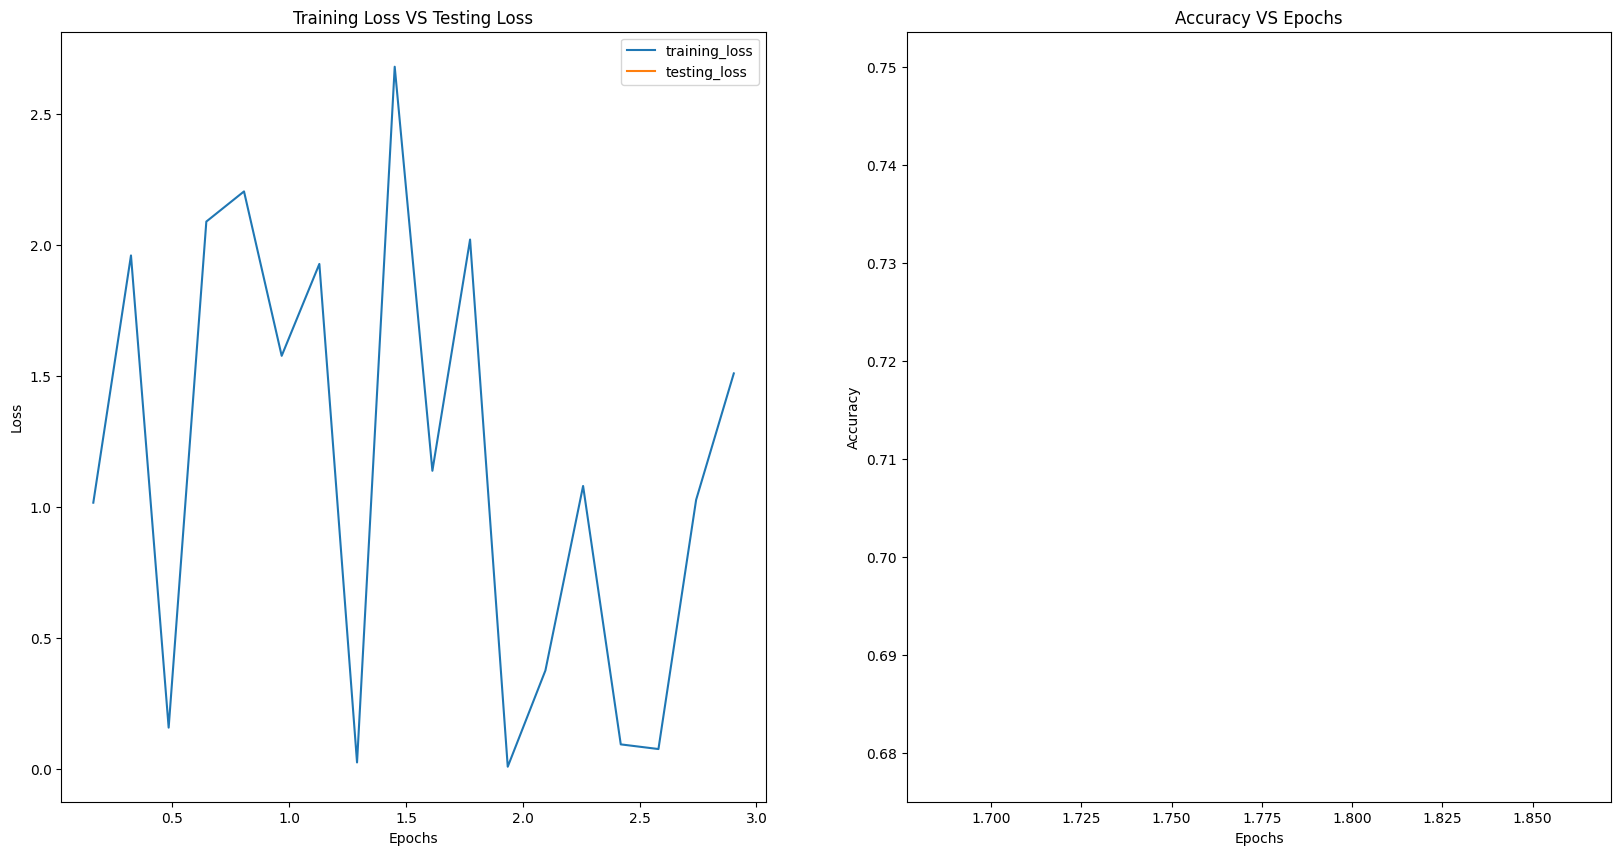

In [53]:
fig,(ax1,ax2) = plt.subplots(nrows = 1 , ncols = 2 , figsize=(20,10))

ax1.plot(training_epochs,training_loss,label="training_loss")
ax1.plot(testing_epochs,eval_loss,label="testing_loss")
ax1.legend()
ax1.set_title("Training Loss VS Testing Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")

ax2.plot(testing_epochs,eval_acc)
ax2.set_title("Accuracy VS Epochs")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")

fig.savefig('./training_plots.png')

In [ ]:
!cp -r ./after_training ./drive/MyDrive/DangiCapstone/
!cp -r ./model ./drive/MyDrive/DangiCapstone/
!cp -r ./training_logs.json ./drive/MyDrive/DangiCapstone/
!cp -r ./training_plots.png ./drive/MyDrive/DangiCapstone/

<br/>
<br/>
<br/>

# CUSTOM DATA PREDICTION

In [ ]:
!cp -r ./drive/MyDrive/DangiCapstone/model .

In [ ]:
path = './Abuse014_x264.mp4'

In [ ]:
import cv2 as cv
import torch
import transformers
import numpy as np

num_frames_to_sample = 16
resize_to = (224,224)


def get_video_frames(path):

        try:

          video = cv.VideoCapture(path)
          num_frames = int(video.get(cv.CAP_PROP_FRAME_COUNT))

          gap = num_frames // num_frames_to_sample
          frame_to_pick = 1
          selected_frames = []

          while (frame_to_pick <= num_frames_to_sample):
            frame_index = gap * frame_to_pick
            video.set(cv.CAP_PROP_POS_FRAMES, frame_index-1)
            ret, frame = video.read()
            resized_frame = cv.resize(frame, resize_to)
            selected_frames.append(resized_frame)
            frame_to_pick+=1

          return selected_frames

        except Exception as e:
          print(e)

In [ ]:
frames = get_video_frames(path)
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

model_ckpt = "sayakpaul/videomae-base-finetuned-ucf101-subset"
CLASSES = [ 'Abuse' , 'Arrest' , 'Arson' , 'Assault' , 'Normal' ]
CUSTOM_MODEL_PATH = "./model"

label2id = {label: i for i, label in enumerate(CLASSES)}
id2label = {i: label for label, i in label2id.items()}

image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    CUSTOM_MODEL_PATH,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)



/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
inputs = image_processor(frames, return_tensors="pt")
inputs['pixel_values'].shape

torch.Size([1, 16, 3, 224, 224])

In [ ]:
with torch.no_grad():
  outputs = model(**inputs)
  logits = outputs.logits

predicted_class = CLASSES[np.argmax(logits)]
print(predicted_class)

Abuse
